## Creating Dataset

In [23]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

# Data
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.2)
X_train_val, X_cal, y_train_val, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2)

## Network and Parameters
Architecture and Learning Parameters. Additionally training functions

In [18]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

### Training Functions

In [19]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_train_loaders(dataset:TensorDataset, train_idx, val_idx, batch_size:int=256, shuffle:bool=True):
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size)

    return train_loader, val_loader


def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        running_loss += loss.item()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
    avg_loss = running_loss / len(loader)

    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

# Training
Training Network and saving models without calibration


 ===================== Training Fold 0  ===================== 

Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.6459999531507492
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.47459443658590317
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.33498694002628326
Saved new best model to Models/no_cal/fold_0.pth, with new best_val_loss=0.3264707699418068


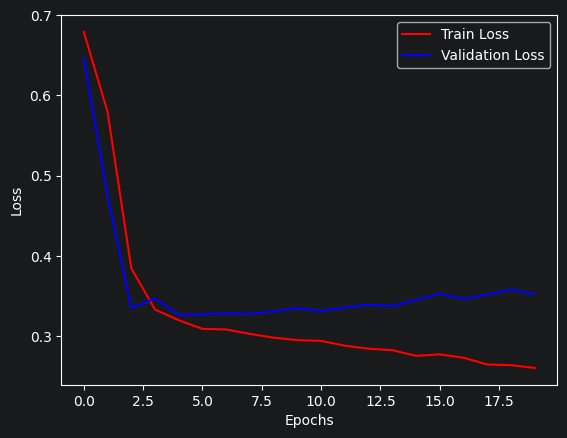


 ===================== Training Fold 1  ===================== 

Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.6452261805534363
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.4885774627327919
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.34081417322158813
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.3375271260738373
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32525772601366043
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32161691039800644
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.32079048454761505
Saved new best model to Models/no_cal/fold_1.pth, with new best_val_loss=0.31881652772426605


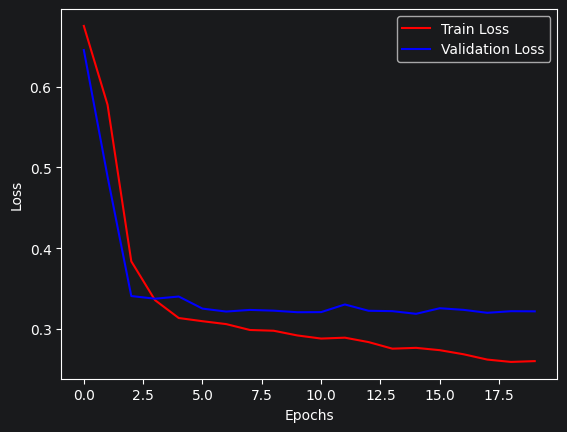


 ===================== Training Fold 2  ===================== 

Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.6447755098342896
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.47328805923461914
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.3354273736476898
Saved new best model to Models/no_cal/fold_2.pth, with new best_val_loss=0.3347155451774597


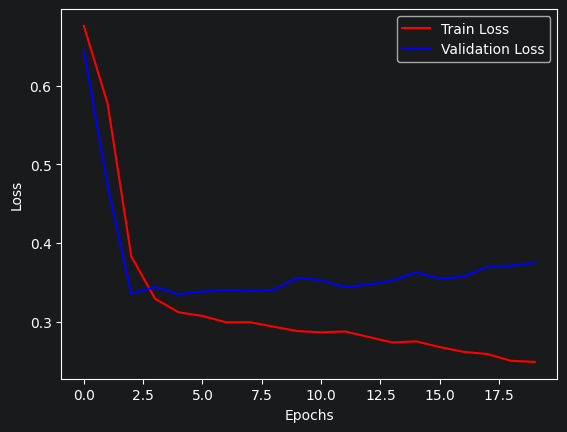


 ===================== Training Fold 3  ===================== 

Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.6690243184566498
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.5416742116212845
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3615354523062706
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3611207976937294
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.35704340785741806
Saved new best model to Models/no_cal/fold_3.pth, with new best_val_loss=0.3469751551747322


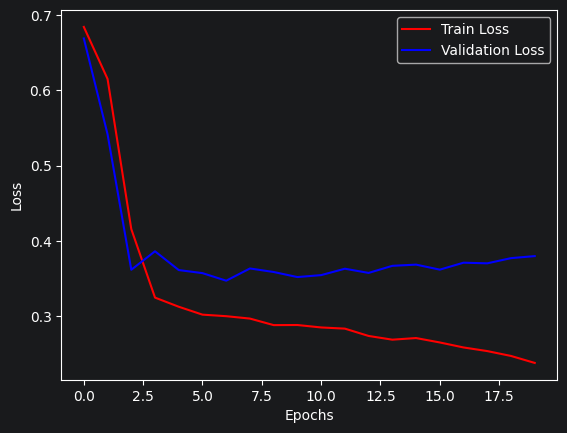


 ===================== Training Fold 4  ===================== 

Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.6502691805362701
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.4908256456255913
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.34098703414201736
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.3254028931260109
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.31902407854795456
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.3189802020788193
Saved new best model to Models/no_cal/fold_4.pth, with new best_val_loss=0.31788182258605957


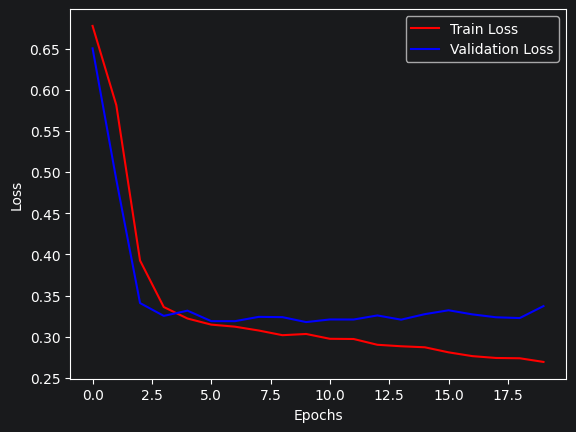

In [26]:
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import os

#paths
write_model_dir = os.path.join('Models', 'no_cal')
os.makedirs(write_model_dir, exist_ok=True)


# Hyperparameter
batch_size = 256
learning_rate = 1e-3 #https://x.com/karpathy/status/801621764144971776?lang=en
n_epochs = 20

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':1
}

# Dataset
trainval_set = TensorDataset(X_train_val_cal, y_train_val_cal)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(trainval_set)))):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')


    # Loaders
    train_loader, val_loader = get_train_loaders(
        dataset=trainval_set,
        train_idx=train_idx,
        val_idx=val_idx,
        batch_size=batch_size,
    )

    # Model, Optimizer, Criterion
    model = MLPClassifier(**model_parameter).to(DEVICE)
    Optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(n_epochs):
        train_loss = _train_one_epoch(model, train_loader, Optimizer, criterion)
        val_loss = _calculate_val_loss(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if best_val_loss > val_loss:
            best_val_loss = val_loss
            model_path = os.path.join(write_model_dir, f"fold_{fold}.pth")
            torch.save(model.state_dict(), model_path)
            print(f'Saved new best model to {model_path}, with new {best_val_loss=}')

    plt.plot(history['train_loss'], label='Train Loss', color='red')
    plt.plot(history['val_loss'], label='Validation Loss', color='blue')
    plt.grid(False)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()